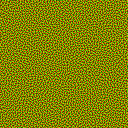

In [209]:
from PIL import Image

path = "C:\\Users\\ckobalt\\Documents\\MasterThesis\\Spatially-Varying-Bokeh\\bokehConfig\\5_fast_noise\\bokeh_fl45.0_as6_samples500000_od500_lidx0of8_0.png"

noisemap_a = Image.open(path)
display(noisemap_a)

In [210]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from PIL import Image
from typing import Tuple

def normalize_offsets(image, *, center: float = 127.5) -> np.ndarray:
    offsets = np.asarray(image)[..., :2].astype(np.float32)
    return (offsets - center) / center

def scatter_index_colored(offsets: np.ndarray, *, cmap: str = "viridis", point_size: float = 3.0, alpha: float = 0.6):
    height, width, _ = offsets.shape
    dx = offsets[..., 0].ravel()
    dy = offsets[..., 1].ravel()

    total_span = max(height + width - 2, 1)
    rows, cols = np.indices((height, width), dtype=np.float32)
    colors = ((rows + cols) / total_span).ravel()

    fig, ax = plt.subplots(figsize=(6, 6))
    scatter = ax.scatter(dx, dy, c=colors, cmap=cmap, s=point_size, alpha=alpha)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("dx")
    ax.set_ylabel("dy")
    ax.set_title("Noise Offsets with Index Gradient")
    fig.colorbar(scatter, ax=ax, label="Mean normalized index")
    return fig, ax

def sort_offsets_by_target(offsets: np.ndarray, target: Tuple[float, float] = (1.0, 1.0)) -> np.ndarray:
    height, width, _ = offsets.shape
    flat = offsets.reshape(-1, 2)
    target_vec = np.asarray(target, dtype=np.float32)

    distance_order = np.argsort(np.linalg.norm(flat - target_vec, axis=1))

    rows, cols = np.indices((height, width))
    rows = rows.ravel()
    cols = cols.ravel()
    position_order = np.lexsort((cols, rows + cols))

    reordered = np.empty_like(flat)
    reordered[position_order] = flat[distance_order]
    return reordered.reshape(height, width, 2)

def offsets_to_image(offsets: np.ndarray):
    uint8_data = ((offsets + 1.0) * 127.5).clip(0, 255).astype(np.uint8)
    rgb = np.zeros((*offsets.shape[:2], 3), dtype=np.uint8)
    rgb[..., :2] = uint8_data
    return Image.fromarray(rgb, mode="RGB")

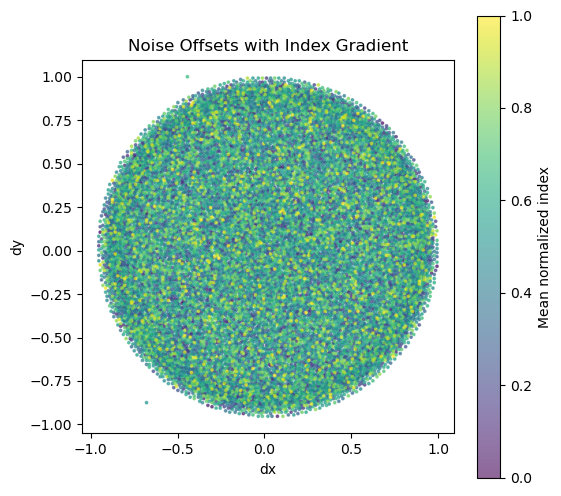

In [211]:
offsets_a = normalize_offsets(noisemap_a)
scatter_index_colored(offsets_a)
plt.show()

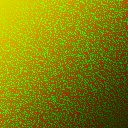

In [212]:
sorted_offsets_a = sort_offsets_by_target(offsets_a)
sorted_image_a = offsets_to_image(sorted_offsets_a)
display(sorted_image_a)

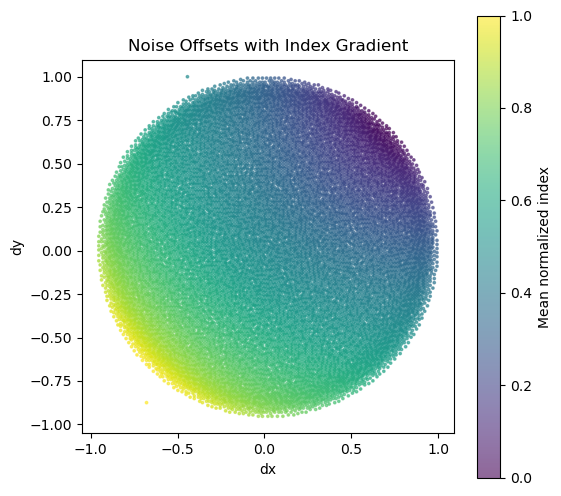

In [213]:
scatter_index_colored(sorted_offsets_a)
plt.show()

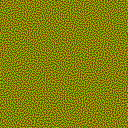

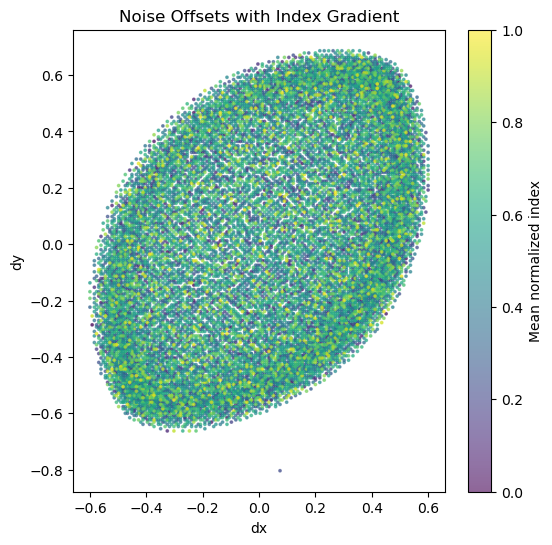

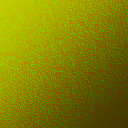

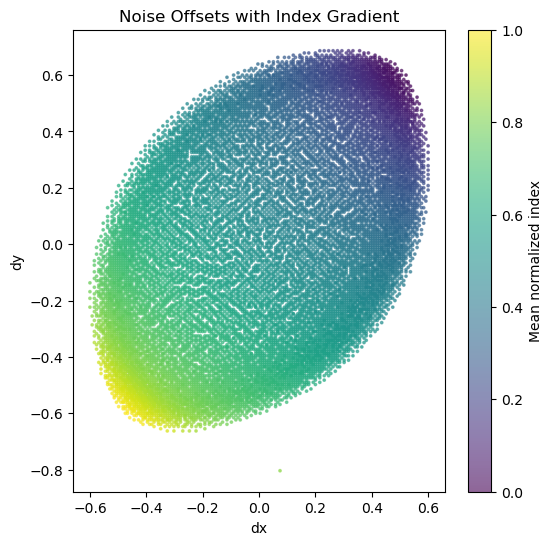

In [214]:
bokeh_map_path = "C:\\Users\\ckobalt\\Documents\\MasterThesis\\Spatially-Varying-Bokeh\\bokehConfig\\5_fast_noise\\bokeh_fl45.0_as6_samples500000_od500_lidx6of8_0.png"

noisemap_b = Image.open(bokeh_map_path)
display(noisemap_b)

offsets_b = normalize_offsets(noisemap_b)
scatter_index_colored(offsets_b)
plt.show()

sorted_offsets_b = sort_offsets_by_target(offsets_b)
sorted_image_b = offsets_to_image(sorted_offsets_b)
display(sorted_image_b)

scatter_index_colored(sorted_offsets_b)
plt.show()

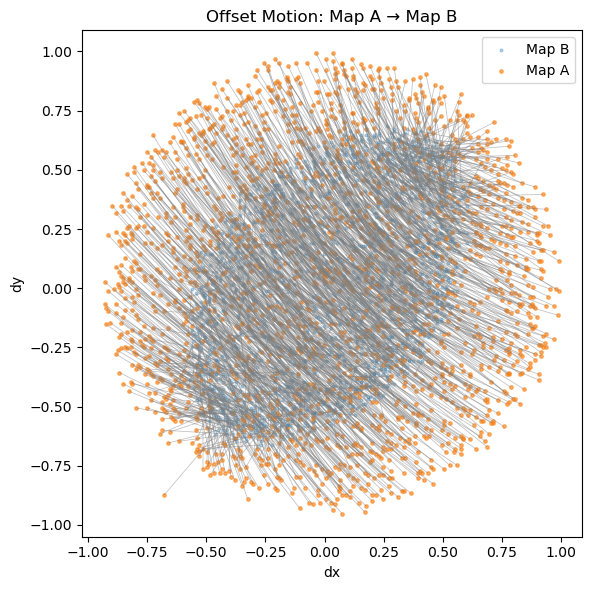

In [215]:
flat_a = sorted_offsets_a.reshape(-1, 2)
flat_b = sorted_offsets_b.reshape(-1, 2)

sample_count = 2000
if flat_a.shape[0] > sample_count:
    idx = np.linspace(0, flat_a.shape[0] - 1, sample_count, dtype=int)
    sample_a = flat_a[idx]
    sample_b = flat_b[idx]
else:
    sample_a = flat_a
    sample_b = flat_b

dx = sample_a[:, 0]
dy = sample_a[:, 1]
du = sample_b[:, 0] - sample_a[:, 0]
dv = sample_b[:, 1] - sample_a[:, 1]

plt.figure(figsize=(6, 6))
plt.scatter(sample_b[:, 0], sample_b[:, 1], s=4, alpha=0.3, color="tab:blue", label="Map B")
plt.scatter(dx, dy, s=6, alpha=0.6, color="tab:orange", label="Map A")
plt.quiver(dx, dy, du, dv, angles="xy", scale_units="xy", scale=1, width=0.0015, color="gray", alpha=0.5)
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("dx")
plt.ylabel("dy")
plt.title("Offset Motion: Map A → Map B")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [216]:
blend_slider = widgets.FloatSlider(value=0.0, min=0.0, max=1.0, step=0.02, description="Blend")

@widgets.interact(t=blend_slider)
def visualize_offset_interpolation(t: float = 0.0):
    interp = sample_a + t * (sample_b - sample_a)
    step = max(1, interp.shape[0] // 800)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(sample_b[:, 0], sample_b[:, 1], s=4, alpha=0.25, color="tab:blue", label="Map B")
    ax.scatter(sample_a[:, 0], sample_a[:, 1], s=4, alpha=0.25, color="tab:orange", label="Map A")
    ax.scatter(interp[:, 0], interp[:, 1], s=8, alpha=0.7, color="tab:green", label="Blend")
    delta = interp - sample_a
    ax.quiver(sample_a[::step, 0], sample_a[::step, 1], delta[::step, 0], delta[::step, 1], angles="xy", scale_units="xy", scale=1, width=0.0012, color="gray", alpha=0.5)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("dx")
    ax.set_ylabel("dy")
    ax.set_title("Interpolated Offsets (t = {:.2f})".format(t))
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

interactive(children=(FloatSlider(value=0.0, description='Blend', max=1.0, step=0.02), Output()), _dom_classes…

# Optimal Transport (OMT)

## Test case

In [217]:
import numpy as np
import ot
from pathlib import Path
from typing import Optional, Tuple
from PIL import Image

pathA = Path("C:/Users/ckobalt/Documents/MasterThesis/Spatially-Varying-Bokeh/bokehConfig/weights/bokeh_fl45.0_as6_samples500000_od500_lidx0of8.png")
pathB = Path("C:/Users/ckobalt/Documents/MasterThesis/Spatially-Varying-Bokeh/bokehConfig/weights/bokeh_fl45.0_as6_samples500000_od500_lidx1of8.png")

desired_resolution: Optional[Tuple[int, int]] = (50,50)  # (height, width); set None to keep native size

def load_gray(path: Path, resolution: Optional[Tuple[int, int]] = None, resample: int = Image.BICUBIC) -> np.ndarray:
    with Image.open(path) as img:
        if resolution is not None:
            target_height, target_width = resolution
            target_height = int(target_height)
            target_width = int(target_width)
            if target_height <= 0 or target_width <= 0:
                raise ValueError("Resolution values must be positive integers")
            if img.size != (target_width, target_height):
                img = img.resize((target_width, target_height), resample=resample)
        data = np.asarray(img, dtype=np.float64)
    if data.ndim == 3:
        data = data[..., 0]
    return np.clip(data, 0.0, None)

density_a = load_gray(pathA, resolution=desired_resolution)
density_b = load_gray(pathB, resolution=desired_resolution)

if density_a.shape != density_b.shape:
    raise ValueError("OT images must share the same resolution")

total_a = density_a.sum()
total_b = density_b.sum()
if total_a == 0 or total_b == 0:
    raise ValueError("Encountered an empty density map")

source_mass = (density_a / total_a).ravel() # flatten to 1D
target_mass = (density_b / total_b).ravel()

# construct unit square coordinates ("pixel positions")
height, width = density_a.shape
unit_y = np.linspace(-1.0, 1.0, height, dtype=np.float64)
unit_x = np.linspace(-1.0, 1.0, width, dtype=np.float64)
unit_mesh_y, unit_mesh_x = np.meshgrid(unit_y, unit_x, indexing="ij")
source_coords = np.stack((unit_mesh_y, unit_mesh_x), axis=-1)
unit_positions = source_coords.reshape(-1, 2)

solution = ot.solve_sample(
    unit_positions,
    unit_positions,
    source_mass,
    target_mass,
    unbalanced=10#, # allow some mass variation penalized in cost function according to unbalanced parameter
    #reg=1e-1,   # allows mass to spread out more, smoothing the transport plan -> sinkhorn algorithm possible for faster computation
 )
plan = solution.plan # how much mass moves from pixel i to pixel j

# average expected target positions to one specific location
plan_row_mass = plan.sum(axis=1)
expected_targets = unit_positions.copy()  # keep identity where the plan has no mass
mass_mask = plan_row_mass > 1e-9
np.divide(plan @ unit_positions, plan_row_mass[:, None], out=expected_targets, where=mass_mask[:, None])

# calculate distortion vectors
omt_vectors = (expected_targets - unit_positions).reshape(height, width, 2)

source_coords_unit = source_coords
divergence = np.linalg.norm(plan_row_mass - source_mass)
print("omt_vectors ready with shape", omt_vectors.shape)
print("plan row-mass divergence", divergence)
print("pixels keeping identity due to low mass", (~mass_mask).sum())

omt_vectors ready with shape (50, 50, 2)
plan row-mass divergence 7.645555772629989e-05
pixels keeping identity due to low mass 543


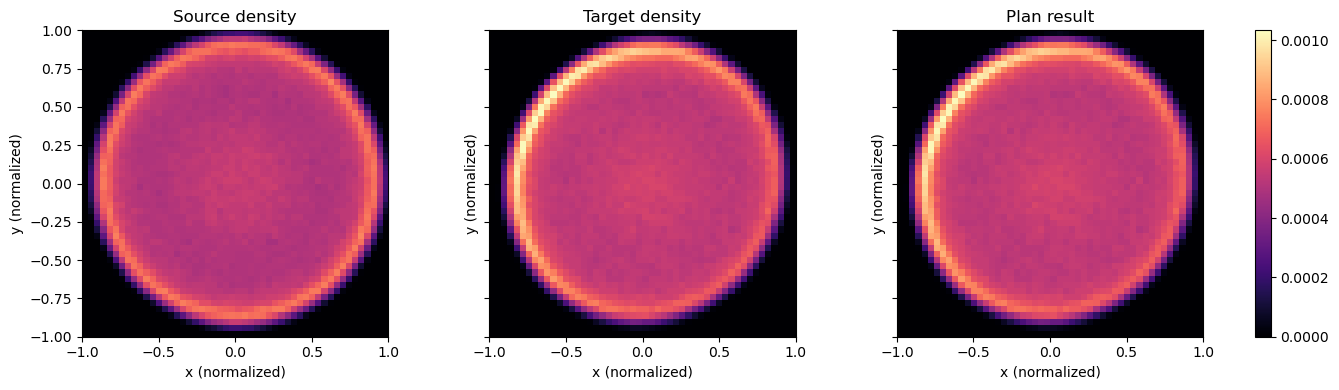

In [218]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors

source_grid = source_mass.reshape(height, width)
target_grid = target_mass.reshape(height, width)
transported_grid = plan.sum(axis=0).reshape(height, width)
transported_grid = transported_grid / transported_grid.sum()

grids = [source_grid, target_grid, transported_grid]
norm = colors.Normalize(
    vmin=min(grid.min() for grid in grids),
    vmax=max(grid.max() for grid in grids),
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True, sharey=True)
titles = ["Source density", "Target density", "Plan result"]

for ax, title, data in zip(axes, titles, grids):
    im = ax.imshow(
        data,
        origin="lower",
        extent=[-1.0, 1.0, -1.0, 1.0],
        cmap="magma",
        norm=norm,
    )
    ax.set_title(title)
    ax.set_xlabel("x (normalized)")
    ax.set_ylabel("y (normalized)")

plt.tight_layout()
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04)
plt.show()

C:\Users\ckobalt\AppData\Local\Temp\1\ipykernel_43888\2516015797.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


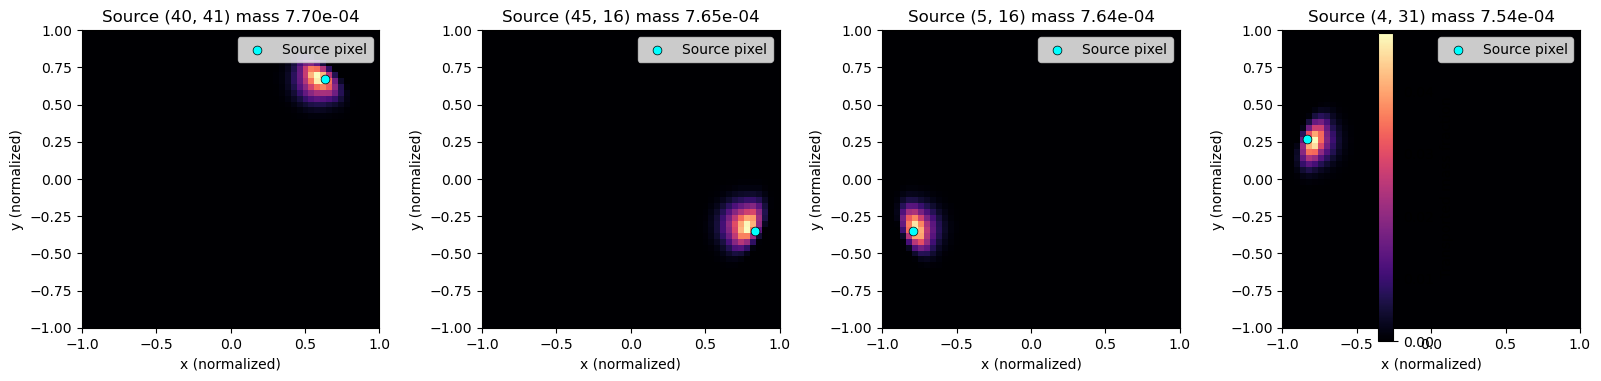

In [219]:
import matplotlib.pyplot as plt
import numpy as np

# surface the spread of a few representative source pixels
top_indices = np.argsort(plan_row_mass)[::-1]
pixels_to_show = []
for flat_idx in top_indices:
    if plan_row_mass[flat_idx] <= 1e-9:
        continue
    y_idx = flat_idx // width
    x_idx = flat_idx % width
    pixels_to_show.append((y_idx, x_idx))
    if len(pixels_to_show) == 4:
        break

if not pixels_to_show:
    raise RuntimeError("No source pixels with sufficient transport mass found.")

fig, axes = plt.subplots(1, len(pixels_to_show), figsize=(4 * len(pixels_to_show), 4))
if len(pixels_to_show) == 1:
    axes = [axes]

for ax, (y_idx, x_idx) in zip(axes, pixels_to_show):
    row_id = y_idx * width + x_idx
    spread = plan[row_id].reshape(height, width)
    if spread.sum() > 0.0:
        spread_display = spread / spread.sum()
    else:
        spread_display = spread

    im = ax.imshow(
        spread_display,
        origin="lower",
        extent=[-1.0, 1.0, -1.0, 1.0],
        cmap="magma",
    )
    ax.scatter(
        source_coords_unit[y_idx, x_idx, 1],
        source_coords_unit[y_idx, x_idx, 0],
        color="cyan",
        s=40,
        edgecolor="black",
        linewidth=0.5,
        label="Source pixel",
    )
    ax.set_title(f"Source ({x_idx}, {y_idx}) mass {plan_row_mass[row_id]:.2e}")
    ax.set_xlabel("x (normalized)")
    ax.set_ylabel("y (normalized)")
    ax.legend(loc="upper right")

cbar = fig.colorbar(im, ax=axes, fraction=0.046, pad=0.04)
cbar.set_label("Transported mass fraction")
plt.tight_layout()
plt.show()

In [220]:
from pathlib import Path
from PIL import Image

# encode normalized distortion vectors into an RGB image (RG = x/y channels)
distortion_map = source_coords_unit + omt_vectors  # reconstruct destination grid before encoding
distortion_xy = np.stack((distortion_map[..., 1], distortion_map[..., 0]), axis=-1)
uint8_data = ((distortion_xy + 1.0) * 127.5).clip(0, 255).astype(np.uint8)
distortion_rgb = np.zeros((height, width, 3), dtype=np.uint8)
distortion_rgb[..., :2] = uint8_data

output_path = pathA.parent / "distortion_vectors.png"
Image.fromarray(distortion_rgb, mode="RGB").save(output_path)
print(f"Saved distortion vectors to {output_path}")

Saved distortion vectors to C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\weights\distortion_vectors.png


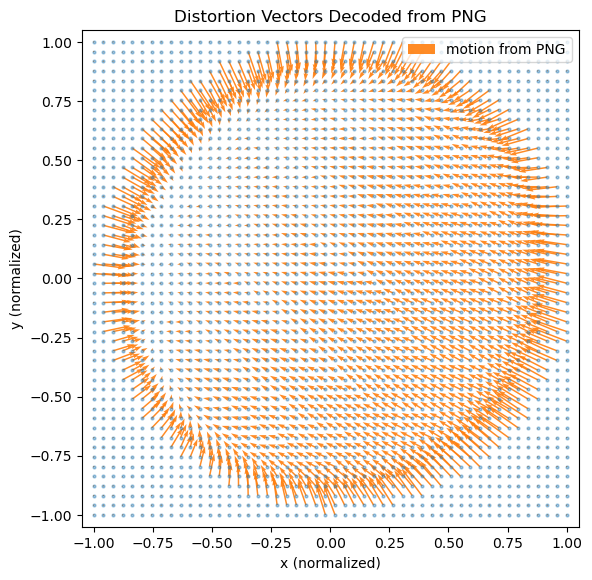

In [221]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

height, width = density_a.shape
step = max(1, int(max(height, width) / 30))

# load saved vectors
encoded = np.asarray(Image.open(pathA.parent / "distortion_vectors.png"), dtype=np.float32)
decoded = (encoded[..., :2] / 127.5) - 1.0
dest_x = decoded[..., 0]
dest_y = decoded[..., 1]

source_x = source_coords_unit[..., 1]
source_y = source_coords_unit[..., 0]

dx = dest_x - source_x
dy = dest_y - source_y

plt.figure(figsize=(6, 6))
plt.quiver(
    source_x[::step, ::step],
    source_y[::step, ::step],
    dx[::step, ::step],
    dy[::step, ::step],
    angles="xy",
    scale_units="xy",
    scale=1.0,
    width=0.003,
    color="tab:orange",
    alpha=0.9,
    pivot="tail",
    label="motion from PNG",
)
plt.scatter(source_x[::step, ::step], source_y[::step, ::step], s=4, color="tab:blue", alpha=0.4)
plt.title("Distortion Vectors Decoded from PNG")
plt.xlabel("x (normalized)")
plt.ylabel("y (normalized)")
plt.xlim(-1.05, 1.05)
plt.ylim(-1.05, 1.05)
plt.gca().set_aspect("equal", adjustable="box")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

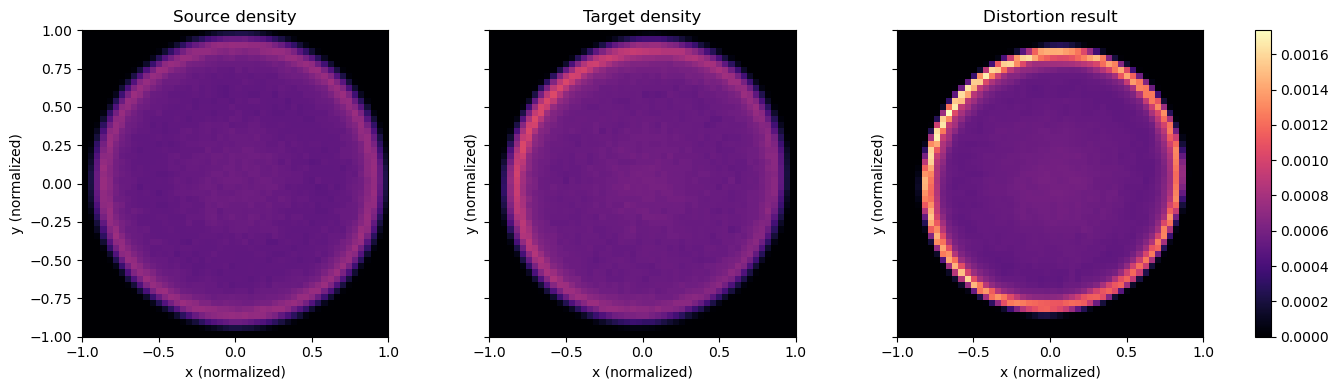

In [222]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors

source_grid = source_mass.reshape(height, width)
target_grid = target_mass.reshape(height, width)
distorted = source_coords_unit + omt_vectors
dest_y_norm = distorted[..., 0]
dest_x_norm = distorted[..., 1]

# map normalized coordinates in [-1, 1] to pixel indices and scatter mass bilinearly
dest_x_px = np.clip((dest_x_norm + 1.0) * 0.5 * (width - 1), 0.0, width - 1.0)
dest_y_px = np.clip((dest_y_norm + 1.0) * 0.5 * (height - 1), 0.0, height - 1.0)

x0 = np.floor(dest_x_px).astype(np.int64)
y0 = np.floor(dest_y_px).astype(np.int64)
x1 = np.clip(x0 + 1, 0, width - 1)
y1 = np.clip(y0 + 1, 0, height - 1)
wx = dest_x_px - x0
wy = dest_y_px - y0
w00 = (1.0 - wx) * (1.0 - wy)
w10 = wx * (1.0 - wy)
w01 = (1.0 - wx) * wy
w11 = wx * wy

expected_density = np.zeros((height, width), dtype=np.float64)
mass_grid = source_grid
np.add.at(expected_density, (y0, x0), mass_grid * w00)
np.add.at(expected_density, (y0, x1), mass_grid * w10)
np.add.at(expected_density, (y1, x0), mass_grid * w01)
np.add.at(expected_density, (y1, x1), mass_grid * w11)

if expected_density.sum() > 0.0:
    expected_density /= expected_density.sum()

grids = [source_grid, target_grid, expected_density]
norm = colors.Normalize(
    vmin=min(grid.min() for grid in grids),
    vmax=max(grid.max() for grid in grids),
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True, sharey=True)
titles = ["Source density", "Target density", "Distortion result"]

for ax, title, data in zip(axes, titles, grids):
    im = ax.imshow(
        data,
        origin="lower",
        extent=[-1.0, 1.0, -1.0, 1.0],
        cmap="magma",
        norm=norm,
    )
    ax.set_title(title)
    ax.set_xlabel("x (normalized)")
    ax.set_ylabel("y (normalized)")

plt.tight_layout()
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04)
plt.show()

baseline loss 0.095670
restart 0 -> final loss 0.001773 (lr=4.0, momentum=0.9, decay=0.9 every 20, loss=ssim)
restart 0 -> final loss 0.001773 (lr=4.0, momentum=0.9, decay=0.9 every 20, loss=ssim)
restart 1 -> final loss 0.001708 (lr=4.0, momentum=0.9, decay=0.9 every 60, loss=ssim)
restart 1 -> final loss 0.001708 (lr=4.0, momentum=0.9, decay=0.9 every 60, loss=ssim)
restart 2 -> final loss 0.001775 (lr=4.0, momentum=0.9, decay=0.8 every 20, loss=ssim)
restart 2 -> final loss 0.001775 (lr=4.0, momentum=0.9, decay=0.8 every 20, loss=ssim)
restart 3 -> final loss 0.001710 (lr=4.0, momentum=0.9, decay=0.8 every 60, loss=ssim)
restart 3 -> final loss 0.001710 (lr=4.0, momentum=0.9, decay=0.8 every 60, loss=ssim)
restart 4 -> final loss 0.001427 (lr=3.5, momentum=0.9, decay=0.9 every 20, loss=ssim)
restart 4 -> final loss 0.001427 (lr=3.5, momentum=0.9, decay=0.9 every 20, loss=ssim)
restart 5 -> final loss 0.001335 (lr=3.5, momentum=0.9, decay=0.9 every 60, loss=ssim)
restart 5 -> final l

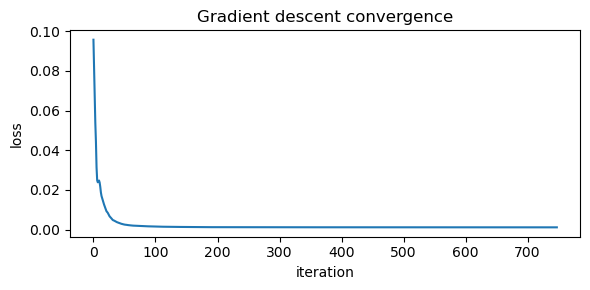

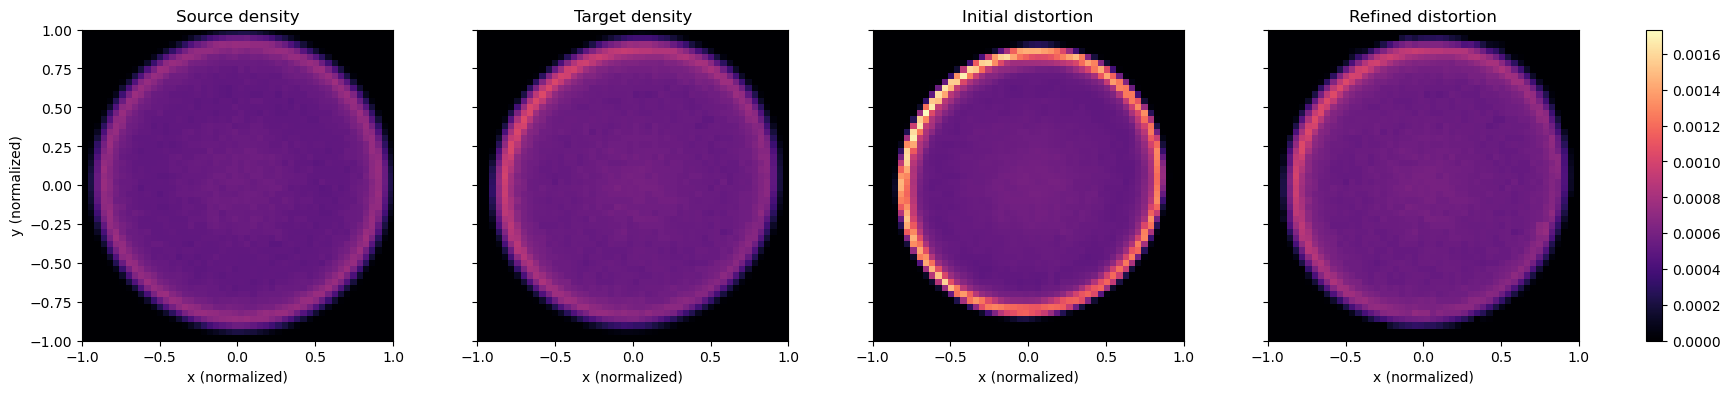

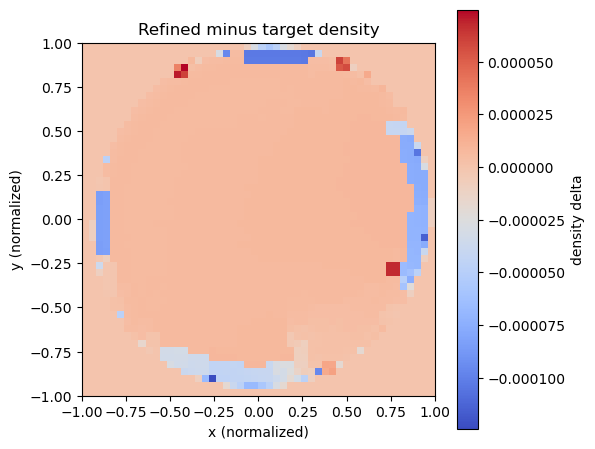

In [256]:
from itertools import product
from matplotlib import colors

def compute_expected_density(field, source_coords, mass_grid):
    height, width = mass_grid.shape
    distorted = source_coords + field
    dest_y_norm = distorted[..., 0]
    dest_x_norm = distorted[..., 1]

    scale_x = 0.5 * (width - 1)
    scale_y = 0.5 * (height - 1)
    dest_x_unclipped = (dest_x_norm + 1.0) * scale_x
    dest_y_unclipped = (dest_y_norm + 1.0) * scale_y

    dest_x_px = np.clip(dest_x_unclipped, 0.0, width - 1.0)
    dest_y_px = np.clip(dest_y_unclipped, 0.0, height - 1.0)

    x0 = np.floor(dest_x_px).astype(np.int64)
    y0 = np.floor(dest_y_px).astype(np.int64)
    x1 = np.clip(x0 + 1, 0, width - 1)
    y1 = np.clip(y0 + 1, 0, height - 1)
    wx = dest_x_px - x0
    wy = dest_y_px - y0

    expected_raw = np.zeros((height, width), dtype=np.float64)
    np.add.at(expected_raw, (y0, x0), mass_grid * (1.0 - wx) * (1.0 - wy))
    np.add.at(expected_raw, (y0, x1), mass_grid * wx * (1.0 - wy))
    np.add.at(expected_raw, (y1, x0), mass_grid * (1.0 - wx) * wy)
    np.add.at(expected_raw, (y1, x1), mass_grid * wx * wy)

    total_mass = expected_raw.sum()
    if total_mass > 0.0:
        expected_density = expected_raw / total_mass
    else:
        expected_density = expected_raw

    aux = (x0, y0, x1, y1, wx, wy, dest_x_unclipped, dest_y_unclipped, total_mass)
    return expected_density, aux


def compute_loss_and_gradient(
    expected_density,
    target_grid,
    *,
    mode="mse", 
    target_energy=None,
    loss_kwargs=None,
):
    if loss_kwargs is None:
        loss_kwargs = {}
    if mode == "mse":
        diff = expected_density - target_grid
        if target_energy is None:
            target_energy = max(np.sum(target_grid * target_grid), 1e-12)
        loss = 0.5 * np.sum(diff * diff) / target_energy
        grad_density = diff / target_energy
        return loss, grad_density
    if mode == "ssim":
        return _ssim_loss_and_grad(expected_density, target_grid, **loss_kwargs)
    raise ValueError(f"Unsupported loss mode '{mode}'")


def _ssim_loss_and_grad(pred, target, data_range=None):
    pred = np.asarray(pred, dtype=np.float64)
    target = np.asarray(target, dtype=np.float64)
    flat_pred = pred.ravel()
    flat_target = target.ravel()
    n = flat_pred.size
    if n == 0:
        return 0.0, np.zeros_like(pred)
    if data_range is None:
        data_min = min(flat_pred.min(), flat_target.min())
        data_max = max(flat_pred.max(), flat_target.max())
        data_range = max(data_max - data_min, 1e-12)
    else:
        data_range = max(float(data_range), 1e-12)
    mu_x = flat_pred.mean()
    mu_y = flat_target.mean()
    r = flat_pred - mu_x
    y_centered = flat_target - mu_y
    sigma_x2 = np.mean(r * r)
    sigma_y2 = np.mean(y_centered * y_centered)
    sigma_xy = np.mean(r * y_centered)
    c1 = (0.01 * data_range) ** 2
    c2 = (0.03 * data_range) ** 2
    a = 2.0 * mu_x * mu_y + c1
    b = 2.0 * sigma_xy + c2
    c = mu_x * mu_x + mu_y * mu_y + c1
    d = sigma_x2 + sigma_y2 + c2
    eps = 1e-12
    a_safe = np.copysign(max(abs(a), eps), a)
    b_safe = np.copysign(max(abs(b), eps), b)
    c_safe = np.copysign(max(abs(c), eps), c)
    d_safe = np.copysign(max(abs(d), eps), d)
    ssim = (a * b) / (c * d)
    ssim = np.clip(ssim, -1.0, 1.0)
    loss = 0.5 * (1.0 - ssim)
    if n == 1:
        grad_flat = np.array([-0.5 * ssim * ((2.0 * mu_y / a_safe) - (2.0 * mu_x / c_safe)) / n])
        return loss, grad_flat.reshape(pred.shape)
    inv_n = 1.0 / n
    alpha = (1.0 - inv_n) * inv_n
    dA_over_A = (2.0 * mu_y * inv_n) / a_safe
    dC_over_C = (2.0 * mu_x * inv_n) / c_safe
    dB_over_B = (2.0 * alpha * y_centered) / b_safe
    dD_over_D = (2.0 * alpha * r) / d_safe
    total_delta = (dA_over_A - dC_over_C) + (dB_over_B - dD_over_D)
    grad_flat = -0.5 * ssim * total_delta
    grad_flat = np.nan_to_num(grad_flat, copy=False)
    return loss, grad_flat.reshape(pred.shape)


def refine_omt_vectors(
    omt_field,
    source_coords,
    source_mass,
    target_mass,
    *,
    learning_rate=0.05,
    momentum=0.8,
    max_iters=2000,
    tolerance=1e-8,
    verbose=False,
    log_every=25,
    decay_rate=0.95,
    decay_interval=100,
    loss_mode="mse",
    loss_kwargs=None,
):
    height, width = source_coords.shape[:2]
    source_grid = source_mass.reshape(height, width)
    target_grid = target_mass.reshape(height, width)
    target_energy = max(np.sum(target_grid * target_grid), 1e-12)
    loss_kwargs = {} if loss_kwargs is None else dict(loss_kwargs)
    lr_initial = float(max(learning_rate, 1e-8))
    min_lr = lr_initial * 1e-2
    decay_interval = int(max(decay_interval, 0))
    decay_rate = float(np.clip(decay_rate, 1e-4, 0.999))
    momentum = float(np.clip(momentum, 0.0, 0.999))
    field = omt_field.copy()
    velocity = np.zeros_like(field)
    loss_history = []
    for step in range(max_iters):
        expected_density, aux = compute_expected_density(field, source_coords, source_grid)
        loss, grad_density = compute_loss_and_gradient(
            expected_density,
            target_grid,
            mode=loss_mode,
            target_energy=target_energy,
            loss_kwargs=loss_kwargs,
        )
        loss_history.append(loss)
        total_mass = aux[-1]
        if total_mass > 0.0:
            coupling = np.sum(grad_density * expected_density)
            grad_raw = (grad_density - coupling) / total_mass
        else:
            grad_raw = grad_density
        x0, y0, x1, y1, wx, wy, dest_x_unclipped, dest_y_unclipped, _ = aux
        g00 = grad_raw[y0, x0]
        g10 = grad_raw[y0, x1]
        g01 = grad_raw[y1, x0]
        g11 = grad_raw[y1, x1]
        grad_dest_x = source_grid * (
            g10 * (1.0 - wy)
            + g11 * wy
            - g00 * (1.0 - wy)
            - g01 * wy
        )
        grad_dest_y = source_grid * (
            g01 * (1.0 - wx)
            + g11 * wx
            - g00 * (1.0 - wx)
            - g10 * wx
        )
        scale_x = 0.5 * (width - 1)
        scale_y = 0.5 * (height - 1)
        mask_x = (dest_x_unclipped > 0.0) & (dest_x_unclipped < width - 1.0)
        mask_y = (dest_y_unclipped > 0.0) & (dest_y_unclipped < height - 1.0)
        grad_x = grad_dest_x * scale_x * mask_x
        grad_y = grad_dest_y * scale_y * mask_y
        grad_field = np.stack((grad_y, grad_x), axis=-1)
        if decay_interval > 0:
            decay_steps = step // decay_interval
            decay_factor = decay_rate ** decay_steps
        else:
            decay_factor = 1.0
        current_lr = max(lr_initial * decay_factor, min_lr)
        velocity = momentum * velocity + (1.0 - momentum) * grad_field
        field -= current_lr * velocity
        distorted = source_coords + field
        np.clip(distorted, -1.0, 1.0, out=distorted)
        field = distorted - source_coords
        if verbose and (step == 0 or (step + 1) % log_every == 0):
            print(f"iter {step + 1:03d} loss {loss:.6f} (lr {current_lr:.4e})")
        if len(loss_history) > 1 and abs(loss_history[-2] - loss) < tolerance:
            break
    expected_density_final, _ = compute_expected_density(field, source_coords, source_grid)
    return field, expected_density_final, np.asarray(loss_history)


def refine_omt_vectors_with_restarts(
    omt_field,
    source_coords,
    source_mass,
    target_mass,
    *,
    restarts=4,
    jitter_scale=0.04,
    seed=2025,
    search_configs=None,
    loss_mode="mse",
    loss_kwargs=None,
):
    height, width = source_coords.shape[:2]
    source_grid = source_mass.reshape(height, width)
    target_grid = target_mass.reshape(height, width)
    target_energy = max(np.sum(target_grid * target_grid), 1e-12)
    loss_kwargs = {} if loss_kwargs is None else dict(loss_kwargs)
    base_density, _ = compute_expected_density(omt_field, source_coords, source_grid)
    base_loss, _ = compute_loss_and_gradient(
        base_density,
        target_grid,
        mode=loss_mode,
        target_energy=target_energy,
        loss_kwargs=loss_kwargs,
    )
    best_field = omt_field
    best_density = base_density
    best_loss = base_loss
    best_history = np.asarray([base_loss])
    rng = np.random.default_rng(seed)
    runs = []
    if search_configs is None:
        schedule_values = {
            "learning_rate": [4.0, 3.5, 3.0, 2.5, 2.0],
            "momentum": [0.9],
            "max_iters": [2000],
            "tolerance": [5e-11],
            "log_every": [50],
            "decay_rate": [0.9, 0.8],
            "decay_interval": [20, 60],
        }
        keys, value_lists = zip(*schedule_values.items())
        search_configs = [dict(zip(keys, combo)) for combo in product(*value_lists)]
    total_runs = max(restarts, 1)
    for run_idx in range(total_runs):
        cfg = search_configs[min(run_idx, len(search_configs) - 1)].copy()
        verbose = cfg.pop("verbose", False)
        cfg.setdefault("tolerance", 1e-10)
        cfg.setdefault("decay_rate", 0.95)
        cfg.setdefault("decay_interval", 150)
        if run_idx == 0:
            init_field = omt_field
        else:
            noise = rng.normal(scale=jitter_scale, size=omt_field.shape)
            distorted = source_coords + omt_field + noise
            np.clip(distorted, -1.0, 1.0, out=distorted)
            init_field = distorted - source_coords
        field_candidate, density_candidate, history = refine_omt_vectors(
            init_field,
            source_coords,
            source_mass,
            target_mass,
            verbose=verbose,
            loss_mode=loss_mode,
            loss_kwargs=loss_kwargs,
            **cfg,
        )
        if history.size:
            final_loss = history[-1]
        else:
            final_loss, _ = compute_loss_and_gradient(
                density_candidate,
                target_grid,
                mode=loss_mode,
                target_energy=target_energy,
                loss_kwargs=loss_kwargs,
            )
            history = np.asarray([final_loss])
        runs.append(history)
        print(
            "restart",
            run_idx,
            "-> final loss",
            f"{final_loss:.6f}",
            f"(lr={cfg['learning_rate']}, momentum={cfg['momentum']}, decay={cfg['decay_rate']} every {cfg['decay_interval']}, loss={loss_mode})",
        )
        if final_loss + 1e-12 < best_loss:
            best_field = field_candidate
            best_density = density_candidate
            best_loss = final_loss
            best_history = history
    return best_field, best_density, best_history, runs


def plot_refinement_diagnostics(
    source_grid,
    target_grid,
    expected_initial,
    expected_refined,
    loss_history,
    *,
    title_suffix="",
) -> None:
    loss_history = np.asarray(loss_history)
    if loss_history.size:
        plt.figure(figsize=(6, 3))
        plt.plot(loss_history, color="tab:blue")
        plt.xlabel("iteration")
        plt.ylabel("loss")
        base_title = "Gradient descent convergence"
        plt.title(f"{base_title} {title_suffix}".strip())
        plt.tight_layout()
        plt.show()
    grids = [
        ("Source density", source_grid),
        ("Target density", target_grid),
        ("Initial distortion", expected_initial),
        ("Refined distortion", expected_refined),
    ]
    norm = colors.Normalize(
        vmin=min(grid.min() for _, grid in grids),
        vmax=max(grid.max() for _, grid in grids),
    )
    fig, axes = plt.subplots(1, len(grids), figsize=(18, 4), sharex=True, sharey=True)
    for idx, (ax, (title, data)) in enumerate(zip(axes, grids)):
        im = ax.imshow(
            data,
            origin="lower",
            extent=[-1.0, 1.0, -1.0, 1.0],
            cmap="magma",
            norm=norm,
        )
        label = f"{title} {title_suffix}".strip()
        ax.set_title(label)
        ax.set_xlabel("x (normalized)")
        ax.set_ylabel("y (normalized)" if idx == 0 else "")
    fig.tight_layout()
    fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04)
    plt.show()
    diff = expected_refined - target_grid
    plt.figure(figsize=(6, 5))
    plt.imshow(
        diff,
        origin="lower",
        extent=[-1.0, 1.0, -1.0, 1.0],
        cmap="coolwarm",
    )
    plt.colorbar(label="density delta")
    diff_title = "Refined minus target density"
    if title_suffix:
        diff_title = f"{diff_title} {title_suffix}"
    plt.title(diff_title)
    plt.xlabel("x (normalized)")
    plt.ylabel("y (normalized)")
    plt.tight_layout()
    plt.show()


height, width = density_a.shape
source_grid = source_mass.reshape(height, width)
target_grid = target_mass.reshape(height, width)
target_energy = max(np.sum(target_grid * target_grid), 1e-12)
loss_mode = "ssim"
loss_kwargs = {}
expected_density_initial, _ = compute_expected_density(omt_vectors, source_coords_unit, source_grid)
baseline_loss, _ = compute_loss_and_gradient(
    expected_density_initial,
    target_grid,
    mode=loss_mode,
    target_energy=target_energy,
    loss_kwargs=loss_kwargs,
)
print(f"baseline loss {baseline_loss:.6f}")

_, expected_density_refined, gd_loss_history, _ = refine_omt_vectors_with_restarts(
    omt_vectors,
    source_coords_unit,
    source_mass,
    target_mass,
    restarts=20,
    jitter_scale=0.0,
    loss_mode=loss_mode,
    loss_kwargs=loss_kwargs,
)

final_loss = gd_loss_history[-1] if gd_loss_history.size else baseline_loss
print(
    "selected best loss",
    f"{final_loss:.6f}",
    f"(improvement {baseline_loss - final_loss:.6f})",
)

expected_density = expected_density_refined

plot_refinement_diagnostics(
    source_grid,
    target_grid,
    expected_density_initial,
    expected_density_refined,
    gd_loss_history,
)

In [257]:
from pathlib import Path
from PIL import Image

# encode normalized distortion vectors into an RGB image (RG = x/y channels)
distortion_map = source_coords_unit + omt_vectors  # reconstruct destination grid before encoding
distortion_xy = np.stack((distortion_map[..., 1], distortion_map[..., 0]), axis=-1)
uint8_data = ((distortion_xy + 1.0) * 127.5).clip(0, 255).astype(np.uint8)
distortion_rgb = np.zeros((height, width, 3), dtype=np.uint8)
distortion_rgb[..., :2] = uint8_data

output_path = pathA.parent / "distortion_vectors.png"
Image.fromarray(distortion_rgb, mode="RGB").save(output_path)
print(f"Saved distortion vectors to {output_path}")

Saved distortion vectors to C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\weights\distortion_vectors.png


In [258]:
import numpy as np
from PIL import Image

value_min, value_max = -1.0, 1.0

encoded = np.asarray(Image.open(pathA.parent / "distortion_vectors.png"), dtype=np.float32)[..., :2]
dest = (encoded / 127.5) - 1.0

source_y = source_coords_unit[..., 0]
source_x = source_coords_unit[..., 1]
displacement = np.stack((dest[..., 1] - source_y, dest[..., 0] - source_x), axis=-1)
height, width = displacement.shape[:2]

rng = np.random.default_rng(547)
samples_a = offsets_a.reshape(-1, 2)[:, ::-1].astype(np.float64)
samples_a = samples_a[rng.choice(samples_a.shape[0], size=min(2_000, samples_a.shape[0]), replace=False)]

def transport(points: np.ndarray) -> np.ndarray:
    points = points.reshape(-1, 2)
    scaled_y = np.clip((points[:, 0] - value_min) / (value_max - value_min) * (height - 1), 0.0, height - 1)
    scaled_x = np.clip((points[:, 1] - value_min) / (value_max - value_min) * (width - 1), 0.0, width - 1)
    y0 = np.floor(scaled_y).astype(int)
    x0 = np.floor(scaled_x).astype(int)
    y1 = np.clip(y0 + 1, 0, height - 1)
    x1 = np.clip(x0 + 1, 0, width - 1)
    wy = scaled_y - y0
    wx = scaled_x - x0
    disp = (
        (1 - wy)[:, None] * ((1 - wx)[:, None] * displacement[y0, x0] + wx[:, None] * displacement[y0, x1])
        + wy[:, None] * ((1 - wx)[:, None] * displacement[y1, x0] + wx[:, None] * displacement[y1, x1])
    )
    return np.clip(points + disp, value_min, value_max)

samples_b = transport(samples_a)

In [259]:
blend_slider = widgets.FloatSlider(value=0.0, min=0.0, max=1.0, step=0.02, description="Blend")

@widgets.interact(t=blend_slider)
def visualize_offset_interpolation(t: float = 0.0):
    interp = samples_a + t * (samples_b - samples_a)
    step = max(1, interp.shape[0] // 800)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(samples_b[:, 0], samples_b[:, 1], s=4, alpha=0.25, color="tab:blue", label="Map B")
    ax.scatter(samples_a[:, 0], samples_a[:, 1], s=4, alpha=0.25, color="tab:orange", label="Map A")
    ax.scatter(interp[:, 0], interp[:, 1], s=8, alpha=0.7, color="tab:green", label="Blend")
    delta = interp - samples_a
    ax.quiver(samples_a[::step, 0], samples_a[::step, 1], delta[::step, 0], delta[::step, 1], angles="xy", scale_units="xy", scale=1, width=0.0012, color="gray", alpha=0.5)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("dx")
    ax.set_ylabel("dy")
    ax.set_title("Interpolated Offsets (t = {:.2f})".format(t))
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

interactive(children=(FloatSlider(value=0.0, description='Blend', max=1.0, step=0.02), Output()), _dom_classes…

### Optimizing more

## Generalized case

In [260]:
import numpy as np
import ot
from pathlib import Path
from typing import Optional, Tuple
from PIL import Image


def load_images_and_create_distortion_map(
    pathA: Path,
    pathB: Path,
    output_path: Path,
    *,
    resolution: Optional[Tuple[int, int]] = None,
    resample: int = Image.BICUBIC,
    source_override: Optional[np.ndarray] = None,
    loss_mode: str = "ssim",
    loss_kwargs: Optional[dict] = None,
) -> np.ndarray:
    if source_override is not None:
        density_a = np.asarray(source_override, dtype=np.float64)
        if resolution is not None:
            target_height, target_width = int(resolution[0]), int(resolution[1])
            if target_height <= 0 or target_width <= 0:
                raise ValueError("Resolution values must be positive integers")
            if density_a.shape != (target_height, target_width):
                raise ValueError("Overridden source density must match the requested resolution")
    else:
        density_a = load_gray(pathA, resolution=resolution, resample=resample)

    density_b = load_gray(pathB, resolution=resolution, resample=resample)

    if density_a.shape != density_b.shape:
        raise ValueError("OT images must share the same resolution")

    density_a = np.clip(density_a, 0.0, None)
    density_b = np.clip(density_b, 0.0, None)

    total_a = density_a.sum()
    total_b = density_b.sum()
    if total_a == 0 or total_b == 0:
        raise ValueError("Encountered an empty density map")

    source_mass = (density_a / total_a).ravel()
    target_mass = (density_b / total_b).ravel()

    height, width = density_a.shape
    unit_y = np.linspace(-1.0, 1.0, height, dtype=np.float64)
    unit_x = np.linspace(-1.0, 1.0, width, dtype=np.float64)
    unit_mesh_y, unit_mesh_x = np.meshgrid(unit_y, unit_x, indexing="ij")
    source_coords = np.stack((unit_mesh_y, unit_mesh_x), axis=-1)
    unit_positions = source_coords.reshape(-1, 2)

    solution = ot.solve_sample(
        unit_positions,
        unit_positions,
        source_mass,
        target_mass,
        unbalanced=10,
    )
    plan = solution.plan

    plan_row_mass = plan.sum(axis=1)
    expected_targets = unit_positions.copy()
    mass_mask = plan_row_mass > 1e-9
    np.divide(plan @ unit_positions, plan_row_mass[:, None], out=expected_targets, where=mass_mask[:, None])

    omt_vectors = (expected_targets - unit_positions).reshape(height, width, 2)

    source_grid = source_mass.reshape(height, width)
    target_grid = target_mass.reshape(height, width)
    target_energy = max(np.sum(target_grid * target_grid), 1e-12)

    expected_density_initial, _ = compute_expected_density(omt_vectors, source_coords, source_grid)
    baseline_loss, _ = compute_loss_and_gradient(
        expected_density_initial,
        target_grid,
        mode=loss_mode,
        target_energy=target_energy,
        loss_kwargs=loss_kwargs,
    )

    omt_vectors, expected_density_refined, gd_loss_history, _ = refine_omt_vectors_with_restarts(
        omt_vectors,
        source_coords,
        source_mass,
        target_mass,
        restarts=20,
        jitter_scale=0.005,
        loss_mode=loss_mode,
        loss_kwargs=loss_kwargs,
    )

    final_loss = gd_loss_history[-1] if gd_loss_history.size else baseline_loss
    if gd_loss_history.size:
        print(
            "Refined distortion loss",
            f"{final_loss:.6f} (improvement {baseline_loss - final_loss:.6f}) after {len(gd_loss_history)} iterations",
        )
    else:
        print("Refined distortion loss", f"{final_loss:.6f} (no iterative refinement history)")

    pair_label = f"({pathA.name} -> {pathB.name})"
    plot_refinement_diagnostics(
        source_grid,
        target_grid,
        expected_density_initial,
        expected_density_refined,
        gd_loss_history,
        title_suffix=pair_label,
    )

    distortion_map = source_coords + omt_vectors
    distortion_xy = np.stack((distortion_map[..., 1], distortion_map[..., 0]), axis=-1)
    uint8_data = ((distortion_xy + 1.0) * 127.5).clip(0, 255).astype(np.uint8)
    distortion_rgb = np.zeros((height, width, 3), dtype=np.uint8)
    distortion_rgb[..., :2] = uint8_data

    Image.fromarray(distortion_rgb, mode="RGB").save(output_path)
    print(f"Saved distortion map to {output_path}")

    global source_coords_unit
    source_coords_unit = source_coords

    return expected_density_refined

### Load all bokeh shapes and create distortion maps

C:\Users\ckobalt\AppData\Local\anaconda3\Lib\site-packages\ot\backend.py:1424: RuntimeWarning: invalid value encountered in divide
  value = np.sum(p * np.log(p / q + eps))


restart 0 -> final loss 0.001773 (lr=4.0, momentum=0.9, decay=0.9 every 20, loss=ssim)
restart 1 -> final loss 0.001129 (lr=4.0, momentum=0.9, decay=0.9 every 60, loss=ssim)
restart 1 -> final loss 0.001129 (lr=4.0, momentum=0.9, decay=0.9 every 60, loss=ssim)
restart 2 -> final loss 0.001111 (lr=4.0, momentum=0.9, decay=0.8 every 20, loss=ssim)
restart 2 -> final loss 0.001111 (lr=4.0, momentum=0.9, decay=0.8 every 20, loss=ssim)
restart 3 -> final loss 0.001286 (lr=4.0, momentum=0.9, decay=0.8 every 60, loss=ssim)
restart 3 -> final loss 0.001286 (lr=4.0, momentum=0.9, decay=0.8 every 60, loss=ssim)
restart 4 -> final loss 0.000750 (lr=3.5, momentum=0.9, decay=0.9 every 20, loss=ssim)
restart 4 -> final loss 0.000750 (lr=3.5, momentum=0.9, decay=0.9 every 20, loss=ssim)
restart 5 -> final loss 0.000742 (lr=3.5, momentum=0.9, decay=0.9 every 60, loss=ssim)
restart 6 -> final loss 0.002809 (lr=3.5, momentum=0.9, decay=0.8 every 20, loss=ssim)
restart 5 -> final loss 0.000742 (lr=3.5, m

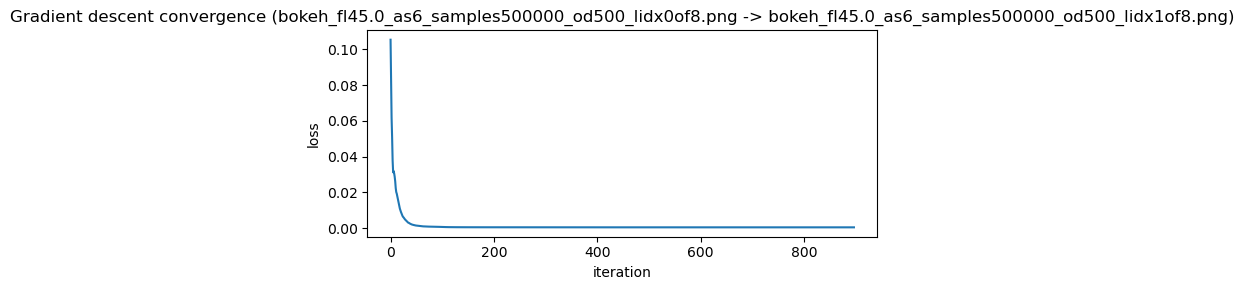

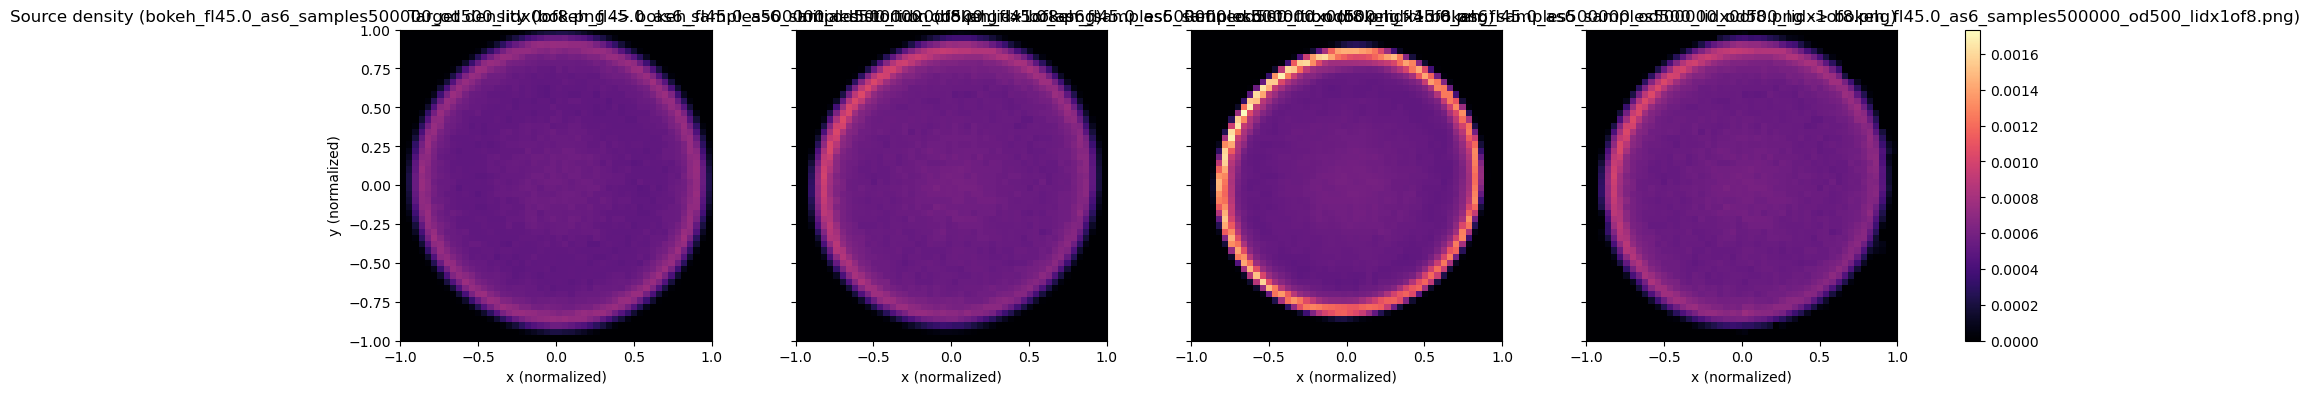

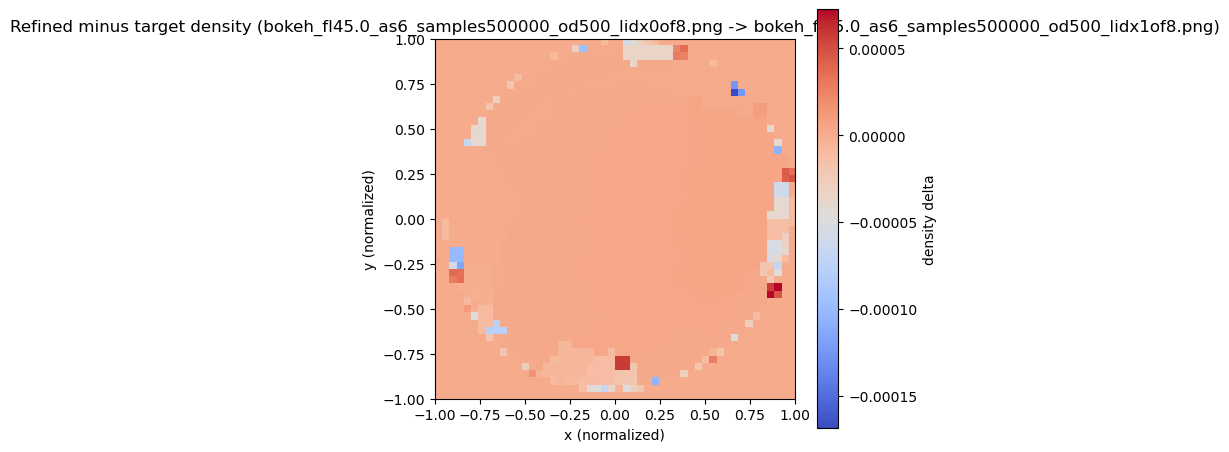

Saved distortion map to C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\distortion_maps\distortion_map_0.png
restart 0 -> final loss 0.000457 (lr=4.0, momentum=0.9, decay=0.9 every 20, loss=ssim)
restart 0 -> final loss 0.000457 (lr=4.0, momentum=0.9, decay=0.9 every 20, loss=ssim)
restart 1 -> final loss 0.000683 (lr=4.0, momentum=0.9, decay=0.9 every 60, loss=ssim)
restart 2 -> final loss 0.000785 (lr=4.0, momentum=0.9, decay=0.8 every 20, loss=ssim)
restart 1 -> final loss 0.000683 (lr=4.0, momentum=0.9, decay=0.9 every 60, loss=ssim)
restart 2 -> final loss 0.000785 (lr=4.0, momentum=0.9, decay=0.8 every 20, loss=ssim)
restart 3 -> final loss 0.001562 (lr=4.0, momentum=0.9, decay=0.8 every 60, loss=ssim)
restart 4 -> final loss 0.000416 (lr=3.5, momentum=0.9, decay=0.9 every 20, loss=ssim)
restart 3 -> final loss 0.001562 (lr=4.0, momentum=0.9, decay=0.8 every 60, loss=ssim)
restart 4 -> final loss 0.000416 (lr=3.5, momentum=0.9, decay=0.9 every 20, loss

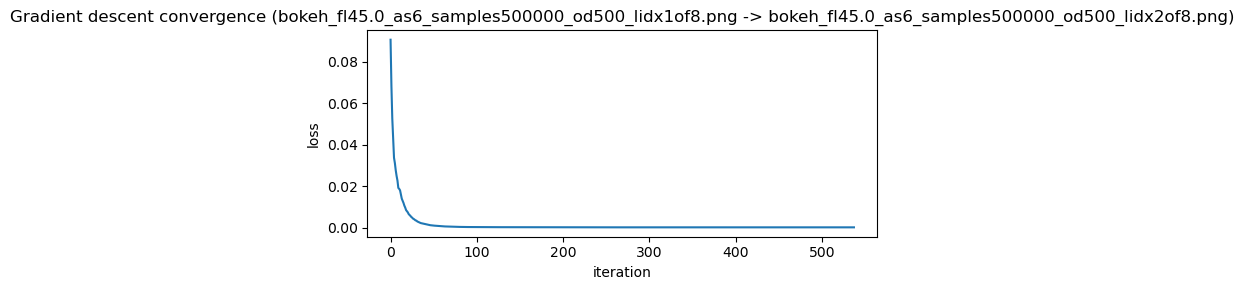

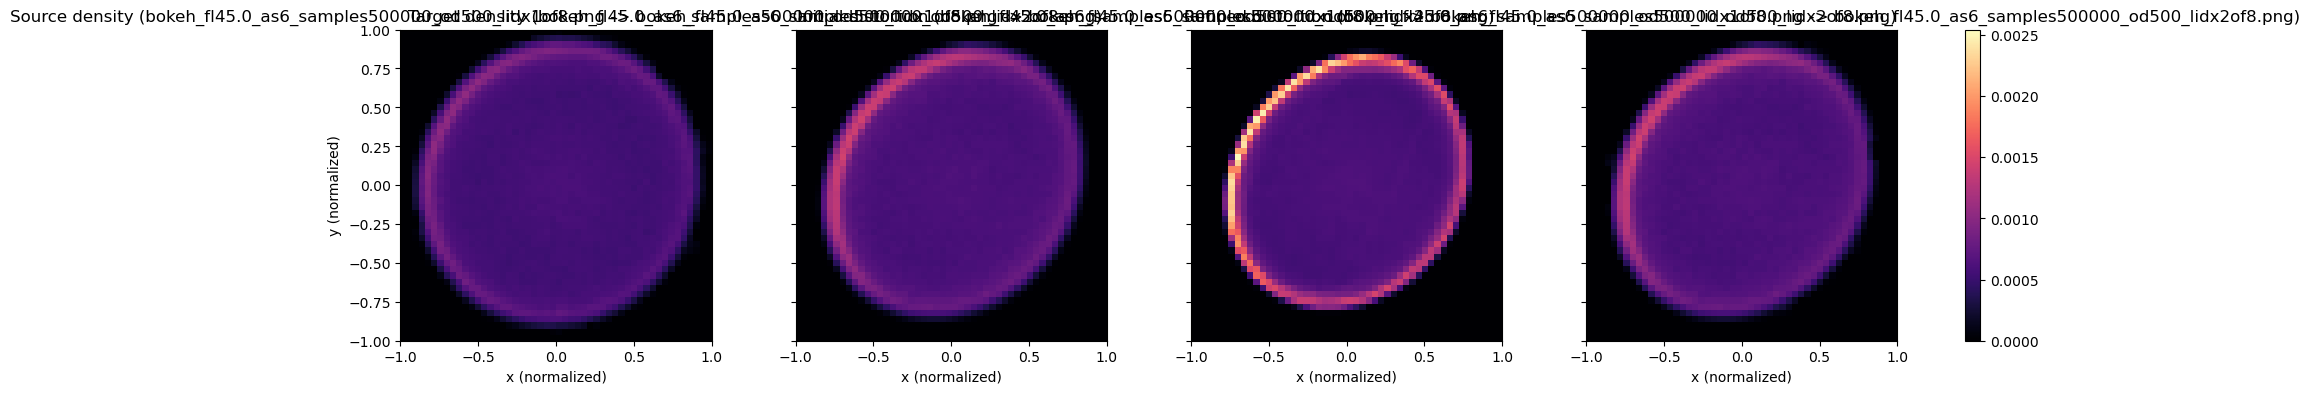

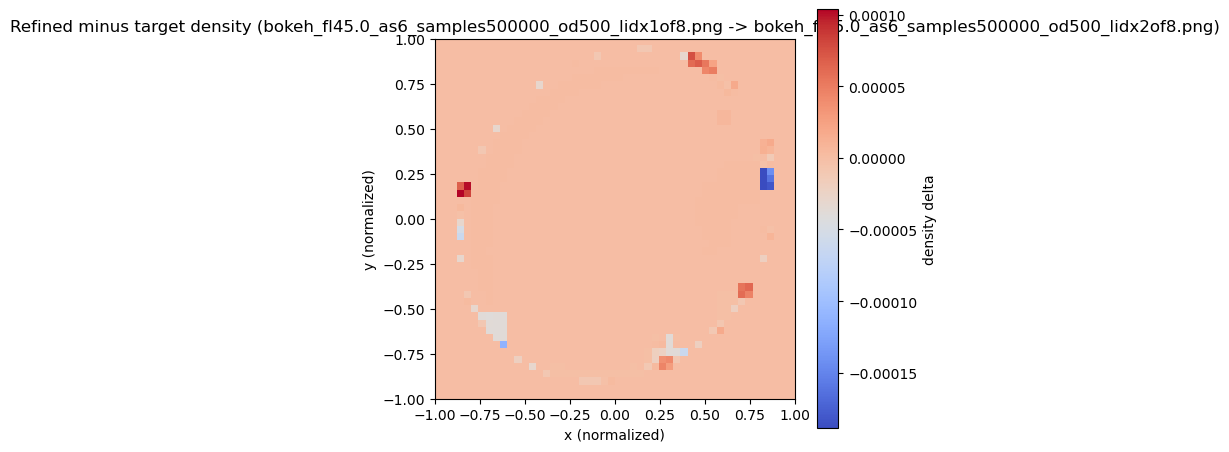

Saved distortion map to C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\distortion_maps\distortion_map_1.png
restart 0 -> final loss 0.001046 (lr=4.0, momentum=0.9, decay=0.9 every 20, loss=ssim)
restart 0 -> final loss 0.001046 (lr=4.0, momentum=0.9, decay=0.9 every 20, loss=ssim)
restart 1 -> final loss 0.000880 (lr=4.0, momentum=0.9, decay=0.9 every 60, loss=ssim)
restart 1 -> final loss 0.000880 (lr=4.0, momentum=0.9, decay=0.9 every 60, loss=ssim)
restart 2 -> final loss 0.001390 (lr=4.0, momentum=0.9, decay=0.8 every 20, loss=ssim)
restart 3 -> final loss 0.000890 (lr=4.0, momentum=0.9, decay=0.8 every 60, loss=ssim)
restart 2 -> final loss 0.001390 (lr=4.0, momentum=0.9, decay=0.8 every 20, loss=ssim)
restart 3 -> final loss 0.000890 (lr=4.0, momentum=0.9, decay=0.8 every 60, loss=ssim)
restart 4 -> final loss 0.000624 (lr=3.5, momentum=0.9, decay=0.9 every 20, loss=ssim)
restart 4 -> final loss 0.000624 (lr=3.5, momentum=0.9, decay=0.9 every 20, loss

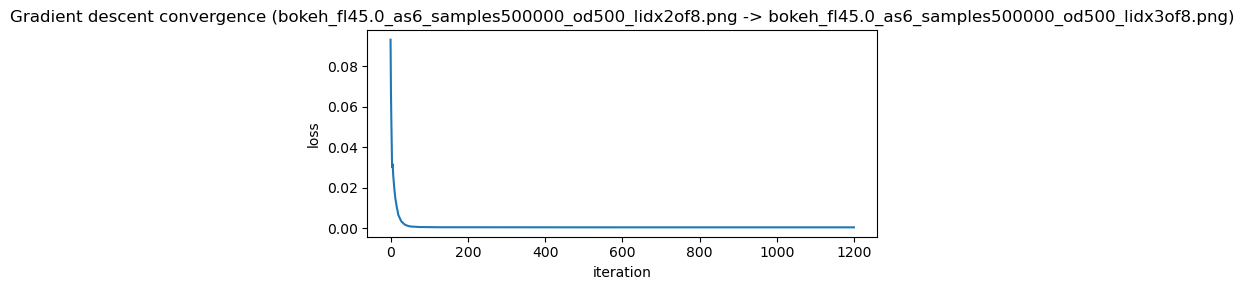

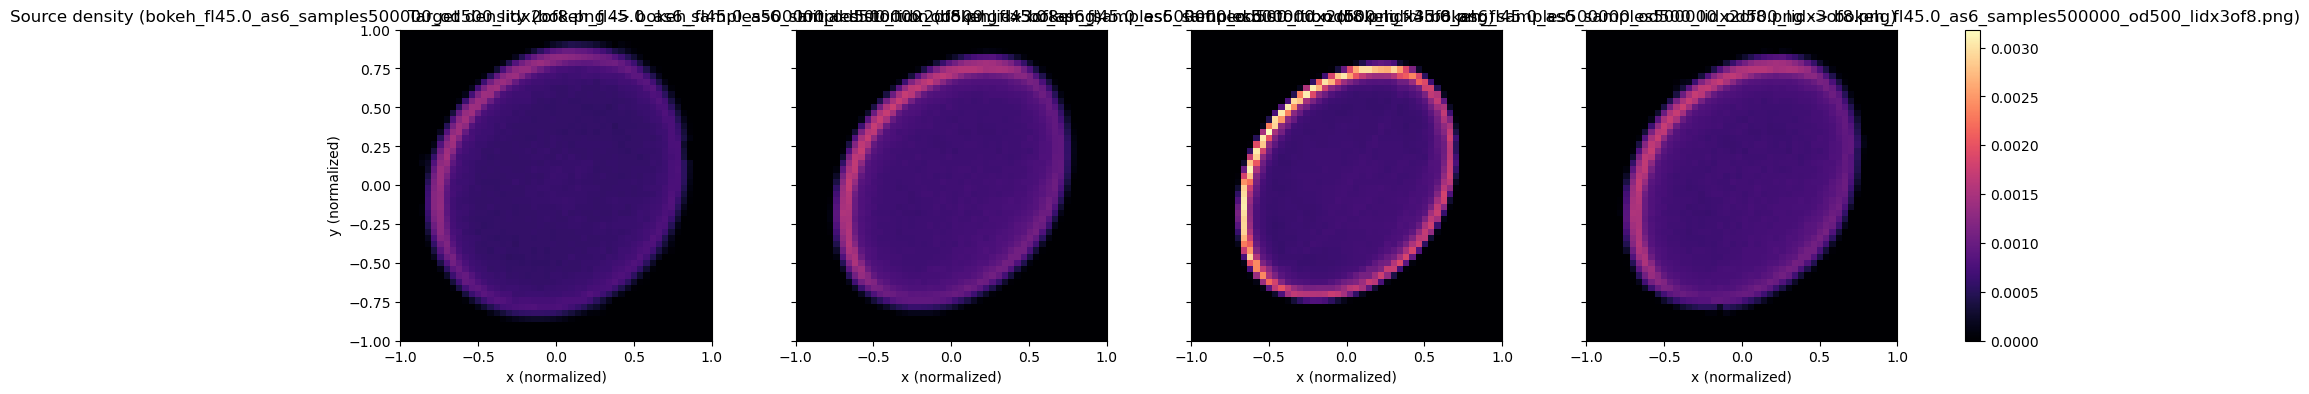

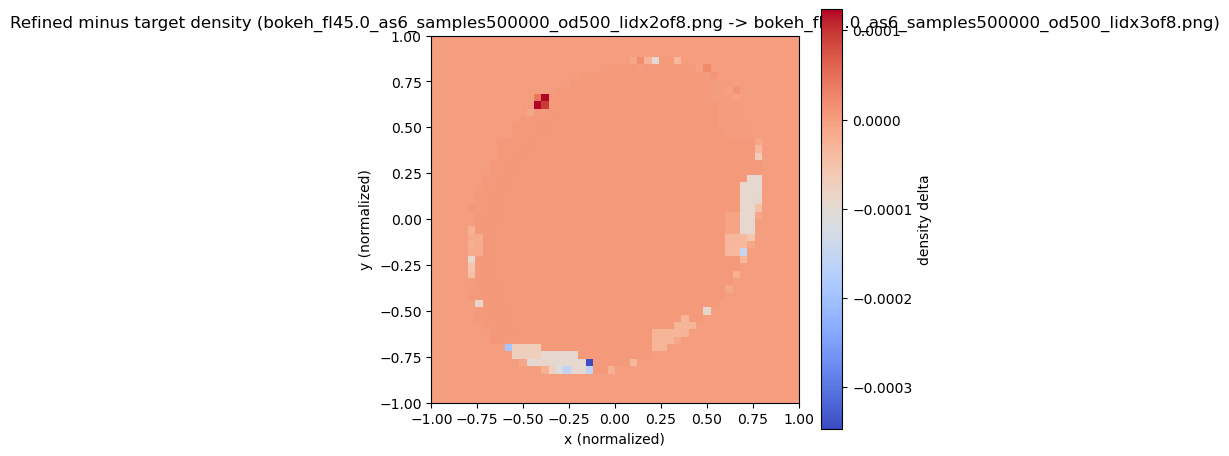

Saved distortion map to C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\distortion_maps\distortion_map_2.png
restart 0 -> final loss 0.000919 (lr=4.0, momentum=0.9, decay=0.9 every 20, loss=ssim)
restart 0 -> final loss 0.000919 (lr=4.0, momentum=0.9, decay=0.9 every 20, loss=ssim)
restart 1 -> final loss 0.001812 (lr=4.0, momentum=0.9, decay=0.9 every 60, loss=ssim)
restart 1 -> final loss 0.001812 (lr=4.0, momentum=0.9, decay=0.9 every 60, loss=ssim)
restart 2 -> final loss 0.002010 (lr=4.0, momentum=0.9, decay=0.8 every 20, loss=ssim)
restart 2 -> final loss 0.002010 (lr=4.0, momentum=0.9, decay=0.8 every 20, loss=ssim)
restart 3 -> final loss 0.000962 (lr=4.0, momentum=0.9, decay=0.8 every 60, loss=ssim)
restart 3 -> final loss 0.000962 (lr=4.0, momentum=0.9, decay=0.8 every 60, loss=ssim)
restart 4 -> final loss 0.000942 (lr=3.5, momentum=0.9, decay=0.9 every 20, loss=ssim)
restart 4 -> final loss 0.000942 (lr=3.5, momentum=0.9, decay=0.9 every 20, loss

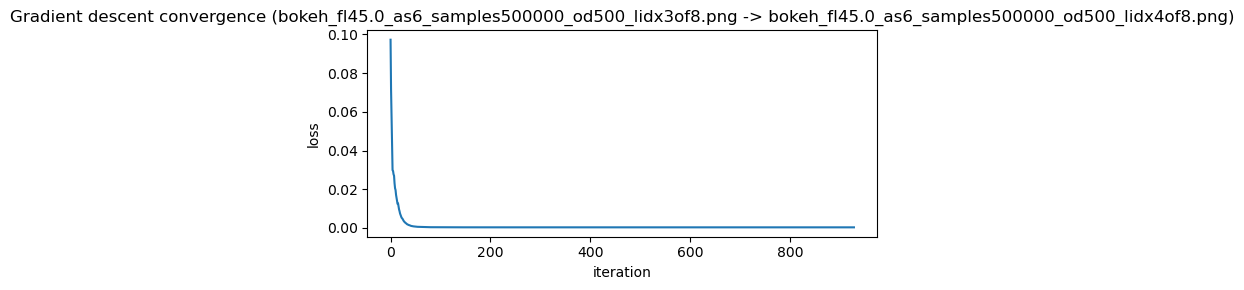

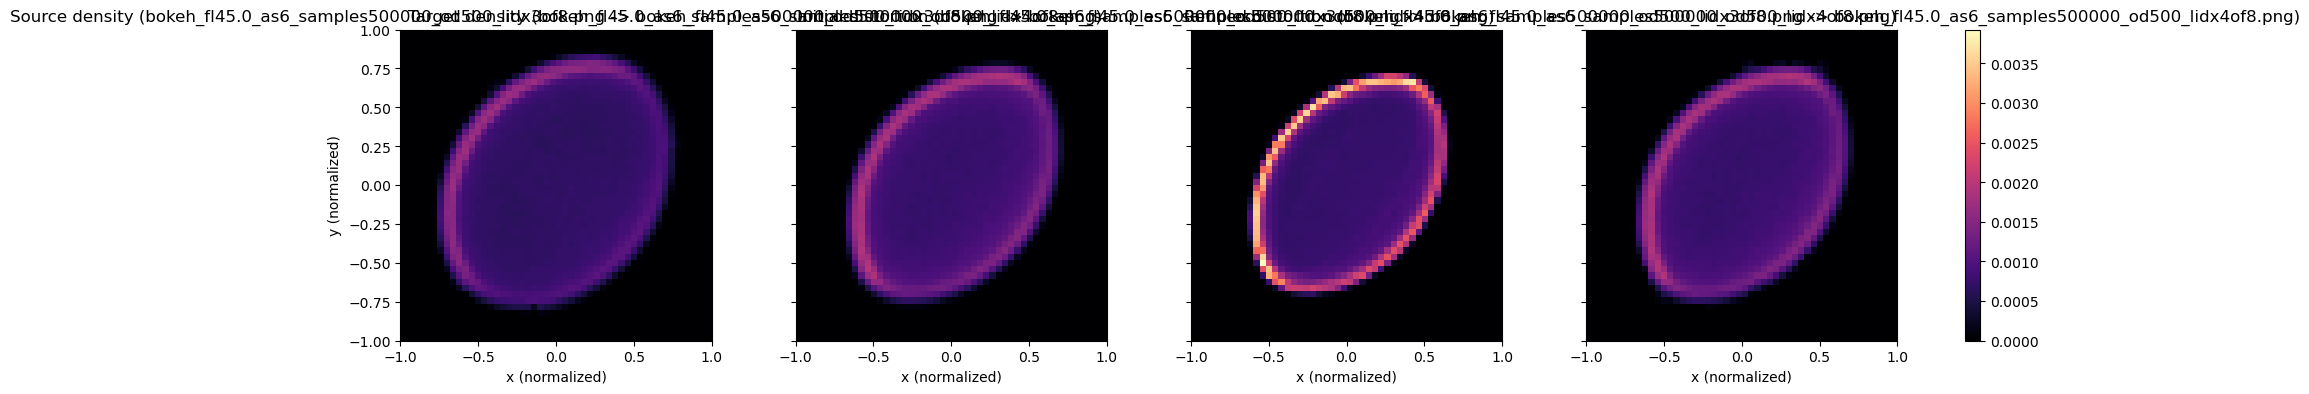

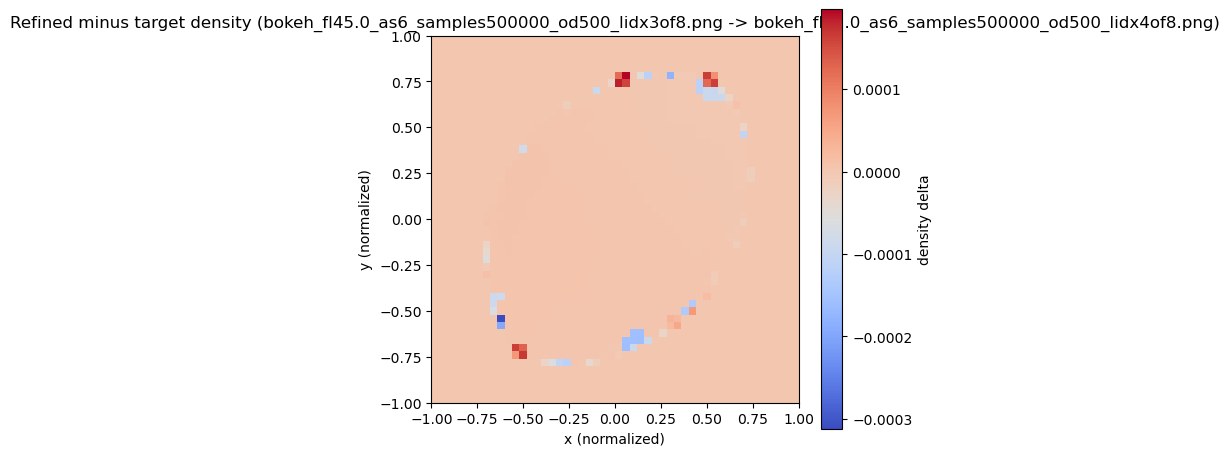

Saved distortion map to C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\distortion_maps\distortion_map_3.png
restart 0 -> final loss 0.000949 (lr=4.0, momentum=0.9, decay=0.9 every 20, loss=ssim)
restart 0 -> final loss 0.000949 (lr=4.0, momentum=0.9, decay=0.9 every 20, loss=ssim)
restart 1 -> final loss 0.001764 (lr=4.0, momentum=0.9, decay=0.9 every 60, loss=ssim)
restart 1 -> final loss 0.001764 (lr=4.0, momentum=0.9, decay=0.9 every 60, loss=ssim)
restart 2 -> final loss 0.001446 (lr=4.0, momentum=0.9, decay=0.8 every 20, loss=ssim)
restart 2 -> final loss 0.001446 (lr=4.0, momentum=0.9, decay=0.8 every 20, loss=ssim)
restart 3 -> final loss 0.003016 (lr=4.0, momentum=0.9, decay=0.8 every 60, loss=ssim)
restart 3 -> final loss 0.003016 (lr=4.0, momentum=0.9, decay=0.8 every 60, loss=ssim)
restart 4 -> final loss 0.002046 (lr=3.5, momentum=0.9, decay=0.9 every 20, loss=ssim)
restart 4 -> final loss 0.002046 (lr=3.5, momentum=0.9, decay=0.9 every 20, loss

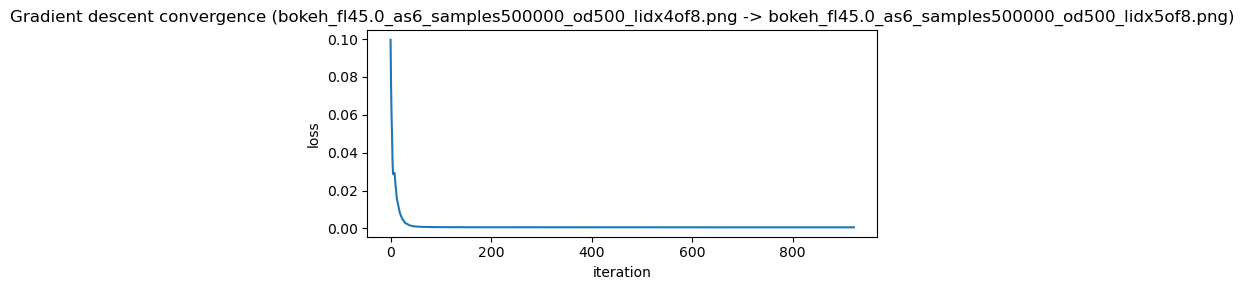

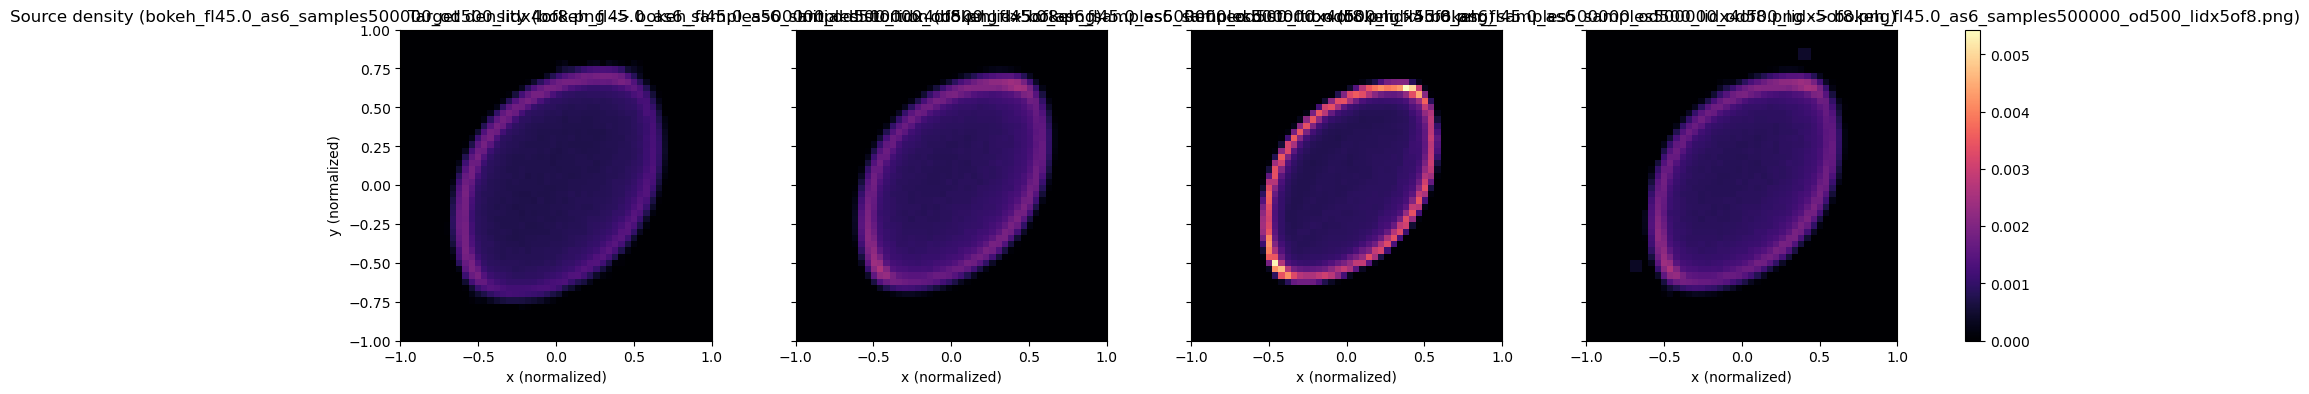

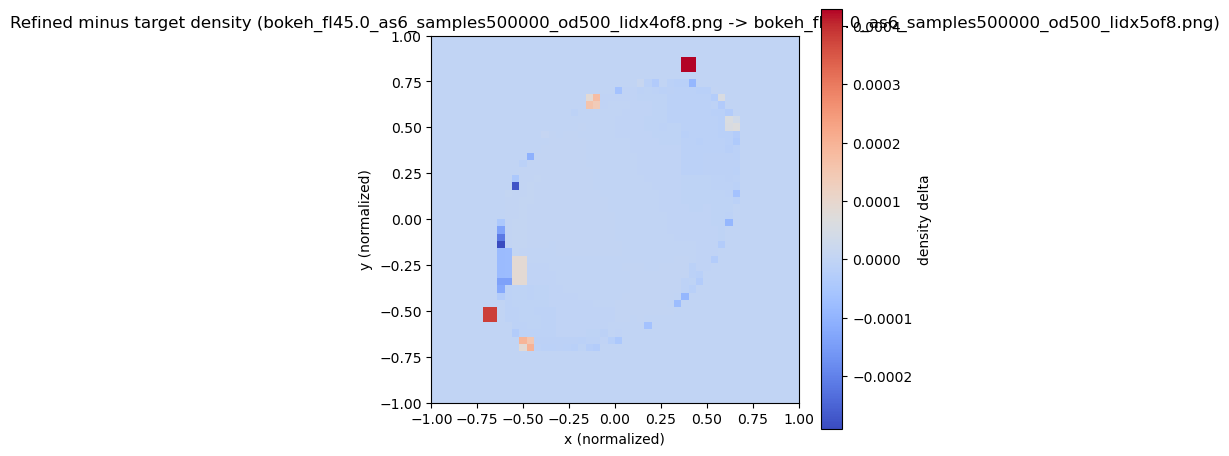

Saved distortion map to C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\distortion_maps\distortion_map_4.png
restart 0 -> final loss 0.002543 (lr=4.0, momentum=0.9, decay=0.9 every 20, loss=ssim)
restart 0 -> final loss 0.002543 (lr=4.0, momentum=0.9, decay=0.9 every 20, loss=ssim)
restart 1 -> final loss 0.000758 (lr=4.0, momentum=0.9, decay=0.9 every 60, loss=ssim)
restart 1 -> final loss 0.000758 (lr=4.0, momentum=0.9, decay=0.9 every 60, loss=ssim)
restart 2 -> final loss 0.001207 (lr=4.0, momentum=0.9, decay=0.8 every 20, loss=ssim)
restart 3 -> final loss 0.003267 (lr=4.0, momentum=0.9, decay=0.8 every 60, loss=ssim)
restart 2 -> final loss 0.001207 (lr=4.0, momentum=0.9, decay=0.8 every 20, loss=ssim)
restart 3 -> final loss 0.003267 (lr=4.0, momentum=0.9, decay=0.8 every 60, loss=ssim)
restart 4 -> final loss 0.001286 (lr=3.5, momentum=0.9, decay=0.9 every 20, loss=ssim)
restart 4 -> final loss 0.001286 (lr=3.5, momentum=0.9, decay=0.9 every 20, loss

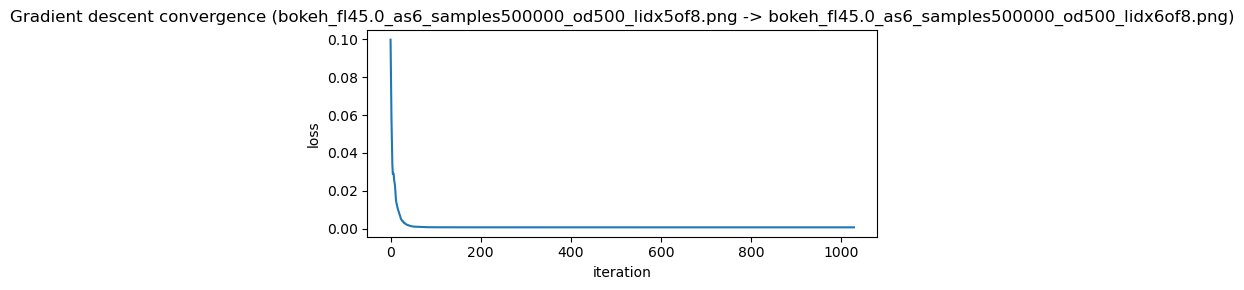

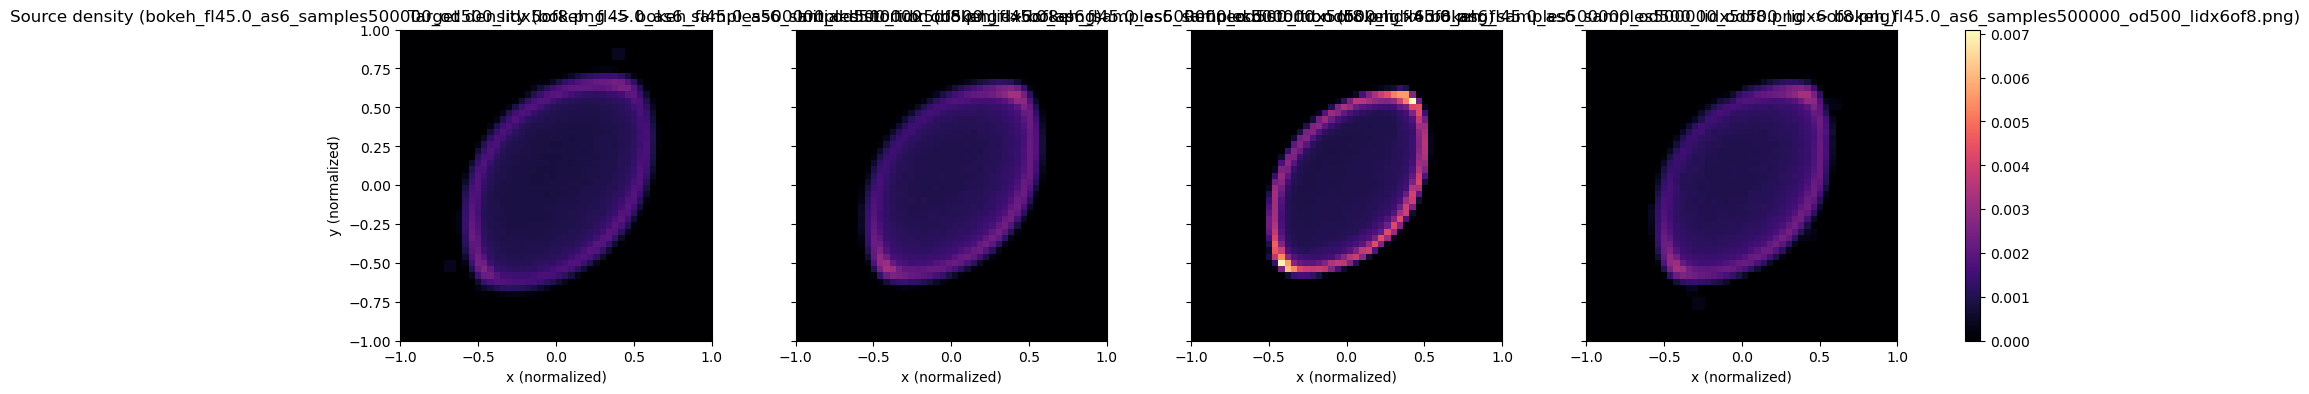

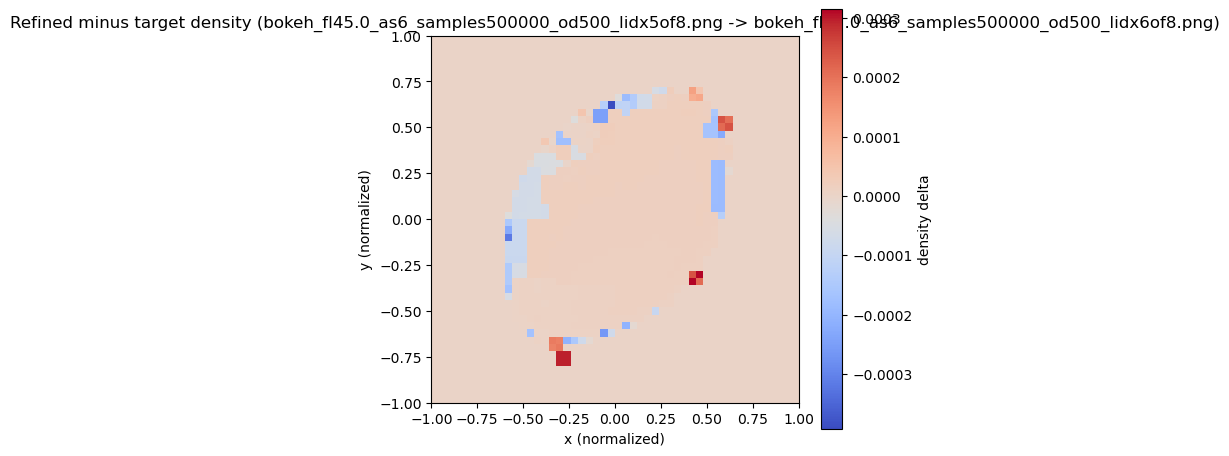

Saved distortion map to C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\distortion_maps\distortion_map_5.png


In [261]:
output_folder = Path("C:/Users/ckobalt/Documents/MasterThesis/Spatially-Varying-Bokeh/bokehConfig/distortion_maps")
desired_resolution = (50, 50)

image_paths = []
for i in range(0, 7):
    image_paths.append(Path(f"C:/Users/ckobalt/Documents/MasterThesis/Spatially-Varying-Bokeh/bokehConfig/weights/bokeh_fl45.0_as6_samples500000_od500_lidx{i}of8.png"))

refined_source = None
for i in range(len(image_paths) - 1):
    refined_source = load_images_and_create_distortion_map(
        image_paths[i],
        image_paths[i + 1],
        output_folder / f"distortion_map_{i}.png",
        resolution=desired_resolution,
        source_override=refined_source,
    )

### Transition noise from one bokeh shape to another

In [262]:
from pathlib import Path

import numpy as np
from PIL import Image

distortion_dir = Path(output_folder)
distortion_maps = sorted(distortion_dir.glob("distortion_map_*.png"))
if not distortion_maps:
    raise FileNotFoundError(f"No distortion maps found in {distortion_dir}")

def load_displacement(path):
    data = np.asarray(Image.open(path), dtype=np.float32)[..., :2]
    dest = (data / 127.5) - 1.0
    dy = dest[..., 1] - source_coords_unit[..., 0]
    dx = dest[..., 0] - source_coords_unit[..., 1]
    return np.stack((dy, dx), axis=-1)

sequence_fields = [load_displacement(path) for path in distortion_maps]
field_height, field_width = sequence_fields[0].shape[:2]

def displacement_at(field, points):
    pts = points.reshape(-1, 2)
    norm = np.clip((pts - value_min) / (value_max - value_min), 0.0, 0.999999)
    y_idx = (norm[:, 0] * (field_height - 1)).astype(int)
    x_idx = (norm[:, 1] * (field_width - 1)).astype(int)
    return field[y_idx, x_idx]

def apply_field(points, field, amount=1.0):
    move = displacement_at(field, points)
    return np.clip(points + amount * move, value_min, value_max)

def move_through_sequence(points, fields, t):
    if not fields:
        return points, 0, 0.0
    total = len(fields)
    progress = np.clip(t, 0.0, 1.0) * total
    segment = min(int(progress), total - 1)
    local = progress - segment
    carried = points.copy()
    for field in fields[:segment]:
        carried = apply_field(carried, field)
    carried = apply_field(carried, fields[segment], amount=local)
    return carried, segment, local

stage_samples = [samples_a]
current = samples_a
for field in sequence_fields:
    current = apply_field(current, field)
    stage_samples.append(current)

segment_titles = [f"Map {i} → {i + 1}" for i in range(len(sequence_fields))]

In [ ]:
def render_sequence_frame(t: float):
    interpolated, segment, local_t = move_through_sequence(samples_a, sequence_fields, t)
    start = stage_samples[segment]
    target = stage_samples[min(segment + 1, len(stage_samples) - 1)]
    step = max(1, interpolated.shape[0] // 800)
    
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(start[:, 0], start[:, 1], s=6, alpha=0.35, color="tab:orange", label=f"Start #{segment}")
    ax.scatter(target[:, 0], target[:, 1], s=6, alpha=0.35, color="tab:blue", label=f"Target #{segment + 1}")
    ax.scatter(interpolated[:, 0], interpolated[:, 1], s=8, alpha=0.7, color="tab:green", label="Interpolated")
    delta = interpolated - start
    ax.quiver(start[::step, 0], start[::step, 1], delta[::step, 0], delta[::step, 1], angles="xy", scale_units="xy", scale=1, width=0.0012, color="gray", alpha=0.45)
    ax.set_xlim(-1.0, 1.0)
    ax.set_ylim(-1.0, 1.0)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("dx")
    ax.set_ylabel("dy")
    ax.set_title(f"{segment_titles[segment]} — global t={t:.3f}, local={local_t:.2f}")
    ax.legend(loc="upper right")
    plt.tight_layout()
    return fig

blend_slider = widgets.FloatSlider(value=0.0, min=0.0, max=1.0, step=0.01, description="Sequence Blend")

@widgets.interact(t=blend_slider)
def visualize_sequence_interpolation(t: float = 0.0):
    fig = render_sequence_frame(t)
    display(fig)
    plt.close(fig)

interactive(children=(FloatSlider(value=0.0, description='Sequence Blend', max=1.0, step=0.01), Output()), _do…